<a href="https://colab.research.google.com/github/SebastianRodriguez05/Teoria_de_Aprendizaje_de_Maquinas-/blob/main/Proyecto_final/linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

In [ ]:
from google.colab import drive
import gdown
import os

# Montar Google Drive
drive.mount('/content/drive')

# Crear ruta destino local
file_id = '1jpW7VNRftEUjVj_yZCOBY6SgA5qa6J4T'
output_path = '/content/cleaned_music_population.csv'

# Descargar desde Google Drive usando gdown
gdown.download(f'https://drive.google.com/uc?id={file_id}', output_path, quiet=False)

# Leer el archivo CSV
df = pd.read_csv(output_path)
df.head()



Mounted at /content/drive


Downloading...
From: https://drive.google.com/uc?id=1jpW7VNRftEUjVj_yZCOBY6SgA5qa6J4T
To: /content/cleaned_music_population.csv
100%|██████████| 4.12M/4.12M [00:00<00:00, 9.09MB/s]


,popularity,acousticness,danceability,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,valence,music_genre
0,27.0,0.00468,0.652,0.941,0.79200,A#,0.115,-5.201,Minor,0.0748,100.889,0.759,Electronic
1,31.0,0.01270,0.622,0.890,0.95000,D,0.124,-7.043,Minor,0.0300,115.002,0.531,Electronic
2,28.0,0.00306,0.620,0.755,0.01180,G#,0.534,-4.617,Major,0.0345,127.994,0.333,Electronic
3,34.0,0.02540,0.774,0.700,0.00253,C#,0.157,-4.498,Major,0.2390,128.014,0.270,Electronic
4,32.0,0.00465,0.638,0.587,0.90900,F#,0.157,-6.266,Major,0.0413,145.036,0.323,Electronic


In [ ]:
df_onehot = pd.get_dummies(df, drop_first=True)
df_onehot.shape, df.shape

((45020, 31), (45020, 13))

In [ ]:
#Eliminating outliers
df_onehot = df_onehot[df_onehot['popularity'] > 0]

Recordar utilizar varibles con one hot emcoding para ver si los modelos mejoran.

In [ ]:
X = df_onehot.drop(columns=['popularity'])
y = df_onehot['popularity']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

In [ ]:
df_results = X_test.copy()
df_results['popularity_real'] = y_test
df_results['popularity_pred'] = y_pred.round(2)

df_results.head(10)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A#,...,music_genre_Blues,music_genre_Classical,music_genre_Country,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,popularity_real,popularity_pred
37548,0.967000,0.516,0.1110,0.028700,0.0997,-17.891,0.0393,134.167,0.1890,False,...,False,True,False,False,False,False,False,False,28.0,35.24
39526,0.985000,0.241,0.0912,0.185000,0.1680,-21.852,0.0520,102.025,0.0784,False,...,False,True,False,False,False,False,False,False,33.0,34.06
6245,0.092100,0.437,0.8900,0.000000,0.1220,-3.043,0.1080,164.946,0.6280,False,...,False,False,False,False,False,False,False,False,37.0,24.93
9271,0.000436,0.300,0.9900,0.007040,0.2850,-3.643,0.1880,125.120,0.1080,False,...,False,False,False,False,False,True,False,False,34.0,41.32
44561,0.486000,0.503,0.5080,0.010200,0.1240,-11.094,0.5200,81.908,0.3170,True,...,False,False,False,False,True,False,False,False,54.0,56.37
10218,0.923000,0.499,0.0341,0.000053,0.1310,-22.310,0.0417,81.735,0.3100,False,...,False,False,False,False,False,True,False,False,62.0,41.62
37150,0.108000,0.541,0.6850,0.824000,0.1530,-6.472,0.0352,125.358,0.4070,False,...,False,True,False,False,False,False,False,False,24.0,33.68
41078,0.618000,0.797,0.5360,0.000000,0.2340,-8.469,0.0370,130.018,0.9250,False,...,False,False,False,False,True,False,False,False,60.0,59.40
14059,0.027300,0.393,0.9360,0.000322,0.3290,-3.390,0.0366,161.904,0.5540,False,...,False,False,False,False,False,False,False,False,42.0,49.99
16261,0.070500,0.875,0.6020,0.000000,0.1600,-5.877,0.0946,119.938,0.8980,False,...,False,False,False,False,False,False,False,False,43.0,50.71


In [ ]:
print('Intercept:', model.intercept_)
print('Coefficients:', model.coef_)

for idx, col_name in enumerate(X.columns):
    print(f'Coefficient for {col_name}: {model.coef_[idx]}')

Intercept: 44.87906518372519
Coefficients: [-4.37293662e-02  2.72263296e-01 -6.79096917e-03 -7.94667812e-01
 -5.08489961e-01  4.49860061e-01 -5.54848797e-01 -3.57094282e-02
 -7.63816677e-02  9.05043685e-03  9.88505135e-02  3.71854717e-03
  8.63751981e-02  6.83824285e-02  1.61806710e-02  4.71322919e-02
 -1.68773777e-02  7.62884691e-02 -6.96877857e-03  1.27748268e-01
  1.32018417e-01 -7.64164328e+00 -4.43203002e+00 -4.28845951e+00
 -1.23937474e+00 -3.36932096e+00  2.52873328e+00 -2.49944199e+00
  3.12368763e+00  2.81546707e+00]
Coefficient for acousticness: -0.04372936624845325
Coefficient for danceability: 0.27226329598925414
Coefficient for energy: -0.006790969171643903
Coefficient for instrumentalness: -0.7946678123128762
Coefficient for liveness: -0.5084899607590138
Coefficient for loudness: 0.44986006135705553
Coefficient for speechiness: -0.5548487967783353
Coefficient for tempo: -0.035709428242878344
Coefficient for valence: -0.07638166765952865
Coefficient for key_A#: 0.009050436

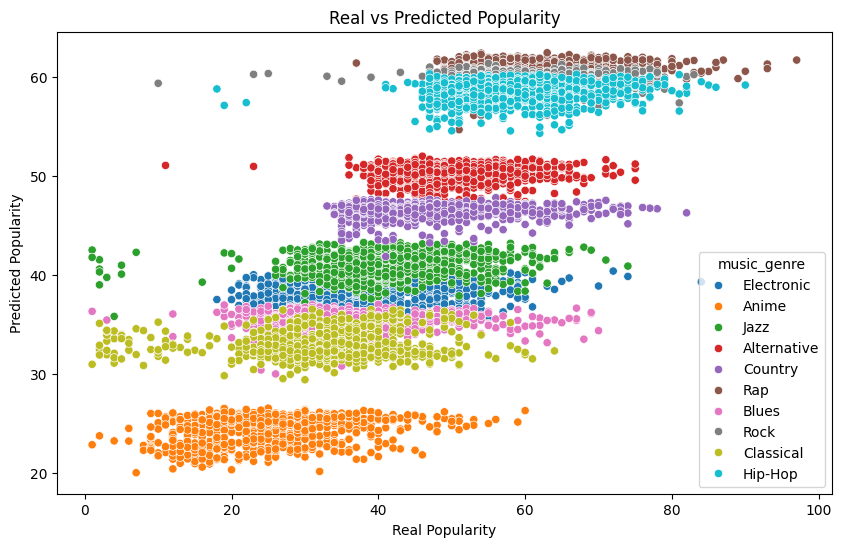

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='popularity_real', y='popularity_pred', data=df_results, hue=df['music_genre'])
plt.title('Real vs Predicted Popularity')
plt.xlabel('Real Popularity')
plt.ylabel('Predicted Popularity')
plt.show()

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

mse = mean_squared_error(y_test, y_pred)
rsme = mse ** 0.5
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print(f'Mean Squared Error: {mse}')
print(f'Root Mean Squared Error: {rsme}')
print(f'R-squared: {r2}')
print(f'Mean Absolute Error: {mae}')


Mean Squared Error: 74.78812493487024
Root Mean Squared Error: 8.648012773745783
R-squared: 0.6514353844968445
Mean Absolute Error: 6.68335800083074


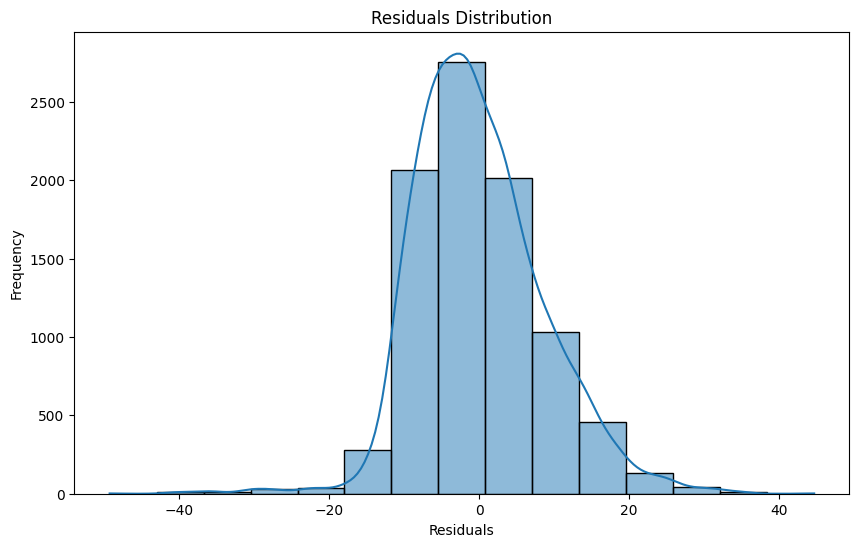

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(y_test - y_pred, bins=15, kde=True)
plt.title('Residuals Distribution')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.show()

In [ ]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor()
dt_model.fit(X_train_scaled, y_train)

y_pred_dt = dt_model.predict(X_test_scaled)

In [ ]:
df_results_tree = X_test.copy()
df_results_tree['popularity_real'] = y_test
df_results_tree['popularity_pred'] = y_pred_dt.round(2)

df_results_tree.head(10)

,acousticness,danceability,energy,instrumentalness,liveness,loudness,speechiness,tempo,valence,key_A#,...,music_genre_Blues,music_genre_Classical,music_genre_Country,music_genre_Electronic,music_genre_Hip-Hop,music_genre_Jazz,music_genre_Rap,music_genre_Rock,popularity_real,popularity_pred
37548,0.967000,0.516,0.1110,0.028700,0.0997,-17.891,0.0393,134.167,0.1890,False,...,False,True,False,False,False,False,False,False,28.0,37.0
39526,0.985000,0.241,0.0912,0.185000,0.1680,-21.852,0.0520,102.025,0.0784,False,...,False,True,False,False,False,False,False,False,33.0,22.0
6245,0.092100,0.437,0.8900,0.000000,0.1220,-3.043,0.1080,164.946,0.6280,False,...,False,False,False,False,False,False,False,False,37.0,23.0
9271,0.000436,0.300,0.9900,0.007040,0.2850,-3.643,0.1880,125.120,0.1080,False,...,False,False,False,False,False,True,False,False,34.0,33.0
44561,0.486000,0.503,0.5080,0.010200,0.1240,-11.094,0.5200,81.908,0.3170,True,...,False,False,False,False,True,False,False,False,54.0,61.0
10218,0.923000,0.499,0.0341,0.000053,0.1310,-22.310,0.0417,81.735,0.3100,False,...,False,False,False,False,False,True,False,False,62.0,49.0
37150,0.108000,0.541,0.6850,0.824000,0.1530,-6.472,0.0352,125.358,0.4070,False,...,False,True,False,False,False,False,False,False,24.0,30.0
41078,0.618000,0.797,0.5360,0.000000,0.2340,-8.469,0.0370,130.018,0.9250,False,...,False,False,False,False,True,False,False,False,60.0,69.0
14059,0.027300,0.393,0.9360,0.000322,0.3290,-3.390,0.0366,161.904,0.5540,False,...,False,False,False,False,False,False,False,False,42.0,40.0
16261,0.070500,0.875,0.6020,0.000000,0.1600,-5.877,0.0946,119.938,0.8980,False,...,False,False,False,False,False,False,False,False,43.0,62.0


En este caso tenemos un peor desempeño para los arboles de decision, deberiamos cambiar parametros para ver si mejora

In [ ]:
mse_tree = mean_squared_error(y_test, y_pred_dt)
rsme_tree = mse_tree ** 0.5
r2_tree = r2_score(y_test, y_pred_dt)
mae_tree = mean_absolute_error(y_test, y_pred_dt)

print(f'Mean Squared Error: {mse_tree}')
print(f'Root Mean Squared Error: {rsme_tree}')
print(f'R-squared: {r2_tree}')
print(f'Mean Absolute Error: {mae_tree}')

Mean Squared Error: 150.36499042684986
Root Mean Squared Error: 12.262340332369261
R-squared: 0.29919469008062616
Mean Absolute Error: 9.449431242257011


Obtuvimos un mejor resultado con el RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42)
model_rf.fit(X_train_scaled, y_train)

y_pred_rf = model_rf.predict(X_test_scaled)

In [ ]:
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f'Mean Squared Error (RF): {mse_rf}')
print(f'Root Mean Squared Error (RF): {rmse_rf}')
print(f'R-squared (RF): {r2_rf}')
print(f'Mean Absolute Error (RF): {mae_rf}')

Mean Squared Error (RF): 75.09274495186035
Root Mean Squared Error (RF): 8.665607015775661
R-squared (RF): 0.6500156436063061
Mean Absolute Error (RF): 6.745893697810243


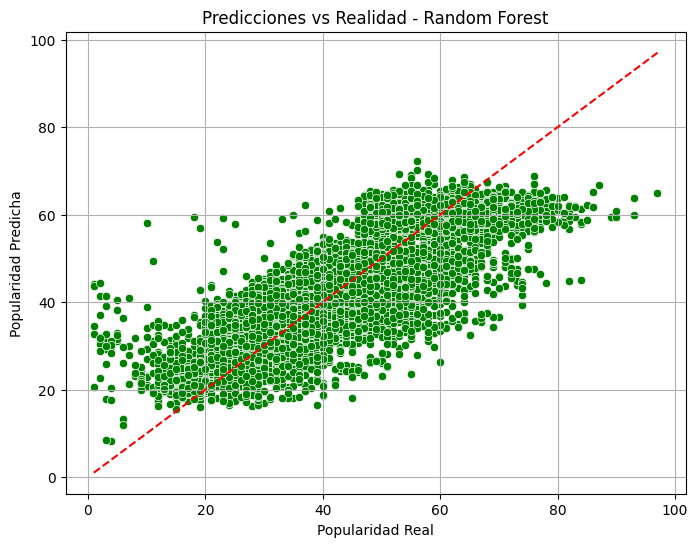

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_rf, color='green')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Popularidad Real")
plt.ylabel("Popularidad Predicha")
plt.title("Predicciones vs Realidad - Random Forest")
plt.grid(True)
plt.show()

In [ ]:
from sklearn.svm import SVR

model_svr = SVR(kernel='linear')
model_svr.fit(X_train_scaled, y_train)

y_pred_svr = model_svr.predict(X_test_scaled)

In [ ]:
mse_svr = mean_squared_error(y_test, y_pred_svr)
rmse_svr = mse_svr ** 0.5
r2_svr = r2_score(y_test, y_pred_svr)
mae_svr = mean_absolute_error(y_test, y_pred_svr)

print(f'Mean Squared Error (SVR): {mse_svr}')
print(f'Root Mean Squared Error (SVR): {rmse_svr}')
print(f'R-squared (SVR): {r2_svr}')
print(f'Mean Absolute Error (SVR): {mae_svr}')

Mean Squared Error (SVR): 76.13206065728997
Root Mean Squared Error (SVR): 8.725368797780984
R-squared (SVR): 0.645171710434229
Mean Absolute Error (SVR): 6.620780919411689


In [ ]:
model_svr_rbf = SVR(kernel='rbf')
model_svr_rbf.fit(X_train_scaled, y_train)

y_pred_svr_rbf = model_svr_rbf.predict(X_test_scaled)

In [ ]:
mse_svr_rbf = mean_squared_error(y_test, y_pred_svr_rbf)
rmse_svr_rbf = mse_svr_rbf ** 0.5
r2_svr_rbf = r2_score(y_test, y_pred_svr_rbf)
mae_svr_rbf = mean_absolute_error(y_test, y_pred_svr_rbf)

print(f'Mean Squared Error (SVR RBF): {mse_svr_rbf}')
print(f'Root Mean Squared Error (SVR RBF): {rmse_svr_rbf}')
print(f'R-squared (SVR RBF): {r2_svr_rbf}')
print(f'Mean Absolute Error (SVR RBF): {mae_svr_rbf}')

Mean Squared Error (SVR RBF): 76.72668066402703
Root Mean Squared Error (SVR RBF): 8.759376728057028
R-squared (SVR RBF): 0.6424003681362468
Mean Absolute Error (SVR RBF): 6.661630525323629


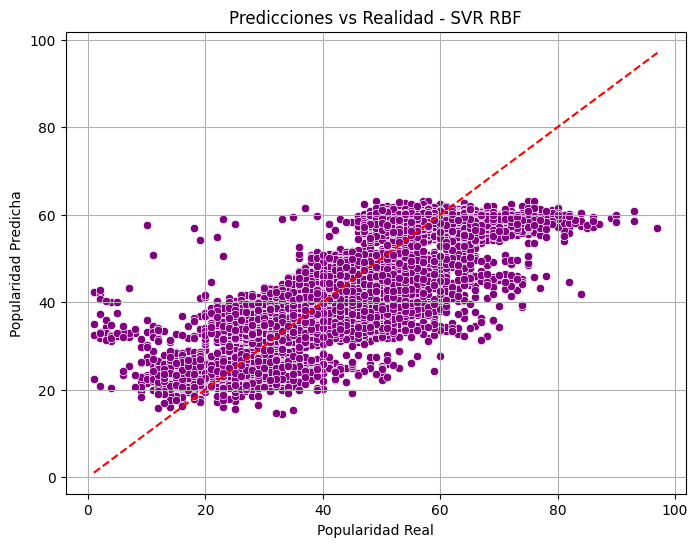

In [ ]:
plt.figure(figsize=(8,6))
sns.scatterplot(x=y_test, y=y_pred_svr_rbf, color='purple')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Popularidad Real")
plt.ylabel("Popularidad Predicha")
plt.title("Predicciones vs Realidad - SVR RBF")
plt.grid(True)
plt.show()